# CS224N 作业 1：探索词向量 (25 分)
### <font color='blue'> 截止时间：2024 年 4 月 9 日（周二）下午 4:30</font>

欢迎来到 CS224N！

开始之前，请务必**阅读与本 notebook 同目录下的 README.md**，其中包含重要的环境配置信息。你需要先安装一些 Python 库才能顺利完成本作业。本 notebook 中提供了大量代码，我们强烈建议你阅读并理解它们，这也是学习的一部分 :)

如果你对 Python、NumPy 或 Matplotlib 不太熟悉，我们建议你参加周五的复习课。该课程会录像，资料会上传到我们的[网站](http://web.stanford.edu/class/cs224n/index.html#schedule)。CS231N 的 Python/NumPy [教程](https://cs231n.github.io/python-numpy-tutorial/)也是很好的资源。

**作业说明：** 请在完成过程中随时保存 notebook。提交说明位于本 notebook 底部。

In [1]:
# All Import Statements Defined Here
# Note: Do not add to this list.
# ----------------

import sys
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 8

from platform import python_version
assert int(python_version().split(".")[1]) >= 5, "Please upgrade your Python version following the instructions in \
    the README.md file found in the same directory as this notebook. Your Python version is " + python_version()

from gensim.models import KeyedVectors
from gensim.test.utils import datapath
import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

from datasets import load_dataset
imdb_dataset = load_dataset("stanfordnlp/imdb")

import re
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

START_TOKEN = '<START>'
END_TOKEN = '<END>'
NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)

# ----------------


## 词向量 (Word Vectors)

词向量常被用作下游 NLP 任务的基础组件，例如问答、文本生成、翻译等，因此建立对其优缺点的直观理解非常重要。在本部分中，你将探索两种类型的词向量：一种来自 *co-occurrence matrix（共现矩阵）*，另一种来自 *GloVe*。

**术语说明：** "word vectors（词向量）"和 "word embeddings（词嵌入）"这两个术语经常互换使用。"embedding（嵌入）"一词指的是我们将单词含义的某些方面编码到一个更低维的空间中。正如 [Wikipedia](https://en.wikipedia.org/wiki/Word_embedding) 所述，"*从概念上讲，它涉及一种数学嵌入：从一个每个单词一个维度的空间，映射到一个维度低得多的连续向量空间*"。


## 第 1 部分：基于计数的词向量 (10 分)

大多数词向量模型的出发点是下面这个想法：

*You shall know a word by the company it keeps（观其友，知其人）（[Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth)）*

许多词向量实现的背后都是这样一个想法：相似的词，即（近似）同义词，会用在相似的上下文中。因此，相似的词往往会与一组共有的词（即上下文）一起出现。通过考察这些上下文，我们可以尝试为单词生成 embedding。基于这种直觉，许多"老派"的词向量构建方法都依赖于词频计数。这里我们详细讲解其中一种策略——*co-occurrence matrix（共现矩阵）*（更多信息见[这里](https://web.stanford.edu/~jurafsky/slp3/6.pdf)或[这里](https://web.archive.org/web/20190530091127/https://medium.com/data-science-group-iitr/word-embedding-2d05d270b285)）。


### Co-Occurrence（共现）

co-occurrence matrix（共现矩阵）统计的是事物在某个环境中一起出现的频率。给定文档中出现的某个词 $w_i$，我们考察围绕 $w_i$ 的 *context window（上下文窗口）*。假设我们的固定窗口大小为 $n$，那么它就是该文档中 $w_i$ 前面 $n$ 个词和后面 $n$ 个词，即词 $w_{i-n} \dots w_{i-1}$ 和 $w_{i+1} \dots w_{i+n}$。我们构建一个 *co-occurrence matrix（共现矩阵）* $M$，它是一个对称的"词 × 词"矩阵，其中 $M_{ij}$ 表示在所有文档中 $w_j$ 出现在 $w_i$ 窗口内的次数。

**示例：固定窗口 n=1 的 Co-Occurrence（共现）**：

文档 1："all that glitters is not gold"

文档 2："all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

在 NLP 中，我们通常用 `<START>` 和 `<END>` 标记来标记句子、段落或文档的开头和结尾。这些标记会包含在 co-occurrence 计数中，用于包裹每个文档，例如："`<START>` All that glitters is not gold `<END>`"。

矩阵的行（或列）给出了基于"词-词共现"的词向量，但这些向量可能维度很高。为了降维，我们采用 Singular Value Decomposition（SVD，奇异值分解），类似于 PCA，选取前 $k$ 个主成分。SVD 过程将共现矩阵 $A$ 分解为对角矩阵 $S$ 中的奇异值，以及 $U_k$ 中新的、更短的词向量。

这种降维能保持语义关系；例如，*doctor* 和 *hospital* 会比 *doctor* 和 *dog* 更接近。

对于不熟悉特征值和 SVD 的同学，这里有一份面向初学者的 SVD 入门介绍 [here](https://davetang.org/file/Singular_Value_Decomposition_Tutorial.pdf)。如需深入理解，可参考 CS168 课程的讲义 [7](https://web.stanford.edu/class/cs168/l/l7.pdf)、[8](http://theory.stanford.edu/~tim/s15/l/l8.pdf) 和 [9](https://web.stanford.edu/class/cs168/l/l9.pdf)，它们对这些算法做了较高层次的讲解。对于实际实现，建议使用 numpy、scipy 或 sklearn 等 Python 包中现成的函数。虽然对大型语料库做完整 SVD 可能很耗内存，但存在 Truncated SVD（截断奇异值分解）等可扩展技术，可以高效地提取前 $k$ 个向量分量。


### 绘制 Co-Occurrence 词嵌入

这里，我们将使用 Large Movie Review Dataset（大型电影评论数据集）。这是一个用于二分类情感分析的数据集，数据量比之前的基准数据集大得多。我们提供 25,000 条极性很强的电影评论用于训练，25,000 条用于测试，另外还有一些未标注的数据可供使用。下面我们提供了一个 `read_corpus` 函数，用于从数据集中提取电影评论的文本。该函数还会给每个文档添加 `<START>` 和 `<END>` 标记，并将单词转为小写。你**不需要**再做任何其他预处理。


In [2]:
def read_corpus():
    """ Read files from the Large Movie Review Dataset.
        Params:
            category (string): category name
        Return:
            list of lists, with words from each of the processed files
    """
    files = imdb_dataset["train"]["text"][:NUM_SAMPLES]
    return [[START_TOKEN] + [re.sub(r'[^\w]', '', w.lower()) for w in f.split(" ")] + [END_TOKEN] for f in files]


让我们看看这些文档是什么样的……。

In [3]:
imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("corpus size: ", len(imdb_corpus[0]))

[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

### 问题 1.1：实现 `distinct_words` [代码] (2 分)

编写一个方法，求出语料库中出现的不同单词（词型，word types）。

你可以用 `for` 循环来处理输入的 `corpus`（一个由字符串列表组成的列表），但建议尝试使用 Python 列表推导式（通常更快）。特别是，[这个链接](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python)对把列表的列表展平会很有用。如果你对 Python 列表推导式不熟悉，这里有[更多信息](https://python-3-patterns-idioms-test.readthedocs.io/en/latest/Comprehensions.html)。

你返回的 `corpus_words` 应该是排好序的。你可以用 Python 的 `sorted` 函数来实现。

你可能会发现用 [Python 集合 (set)](https://www.w3schools.com/python/python_sets.asp) 来去除重复单词很有用。


In [4]:
def distinct_words(corpus):
    """ Determine a list of distinct words for the corpus.
        Params:
            corpus (list of list of strings): corpus of documents
        Return:
            corpus_words (list of strings): sorted list of distinct words across the corpus
            n_corpus_words (integer): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1
    
    # ------------------
    # Write your implementation here.
    corpus_flatten = [y for x in corpus for y in x]
    corpus_words = sorted(list(set(corpus_flatten)))
    n_corpus_words = len(corpus_words)

    # ------------------
    
    
    return corpus_words, n_corpus_words

In [5]:
# ---------------------
# Run this sanity check
# Note that this not an exhaustive check for correctness.
# ---------------------

# Define toy corpus
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert(num_corpus_words == ans_num_corpus_words), "Incorrect number of distinct words. Correct: {}. Yours: {}".format(ans_num_corpus_words, num_corpus_words)

# Test correct words
assert (test_corpus_words == ans_test_corpus_words), "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(str(ans_test_corpus_words), str(test_corpus_words))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### 问题 1.2：实现 `compute_co_occurrence_matrix` [代码] (3 分)

编写一个方法，为某个窗口大小 $n$（默认为 4）构建共现矩阵，考虑窗口中心词前面 $n$ 个词和后面 $n$ 个词。从这里开始，我们用 `numpy (np)` 来表示向量、矩阵和张量。如果你对 NumPy 不熟悉，这份 cs231n 的 [Python NumPy 教程](http://cs231n.github.io/python-numpy-tutorial/) 的后半部分有 NumPy 教程。


In [6]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """ Compute co-occurrence matrix for the given corpus and window_size (default of 4).
    
        Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
              number of co-occurring words.
              
              For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
              "All" will co-occur with "<START>", "that", "glitters", "is", and "not".
    
        Params:
            corpus (list of list of strings): corpus of documents
            window_size (int): size of context window
        Return:
            M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): 
                Co-occurence matrix of word counts. 
                The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
            word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    words, n_words = distinct_words(corpus)
    M = None
    word2ind = {}
    
    # ------------------
    # Write your implementation here.
    M = np.zeros([n_words,n_words])
    for index, w in enumerate(words):
        word2ind[w] = index
    for stc in corpus:
        for index, word in enumerate(stc):
            if index > len(stc) - window_size - 1:
                break
            a_word_index = word2ind[word]
            for i in range(window_size):
                b_word_index = word2ind[stc[index + i + 1]]
                M[a_word_index, b_word_index] += 1
                M[b_word_index, a_word_index] += 1


    
    # ------------------

    return M, word2ind

In [8]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

# Define toy corpus and get student's co-occurrence matrix
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array( 
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert (word2ind_ans == word2ind_test), "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)

# Test correct M shape
assert (M_test.shape == M_test_ans.shape), "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError("Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(idx1, idx2, w1, w2, student, correct))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### 问题 1.3：实现 `reduce_to_k_dim` [代码] (1 分)

编写一个方法，对矩阵进行降维，生成 k 维的 embedding。使用 SVD 取前 k 个分量，生成一个新的 k 维 embedding 矩阵。

**注意：** numpy、scipy 和 scikit-learn（`sklearn`）都提供了 SVD 的*某种*实现，但只有 scipy 和 sklearn 提供了 Truncated SVD 的实现，而只有 sklearn 提供了用于计算大规模 Truncated SVD 的高效随机化算法。因此请使用 [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)。


In [7]:
def reduce_to_k_dim(M, k=2):
    """ Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
        to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
            - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
    
        Params:
            M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
            k (int): embedding size of each word after dimension reduction
        Return:
            M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
                    In terms of the SVD from math class, this actually returns U * S
    """    
    n_iters = 10    # Use this parameter in your call to `TruncatedSVD`
    M_reduced = None
    print("Running Truncated SVD over %i words..." % (M.shape[0]))
    
    # ------------------
    # Write your implementation here.
    svd = TruncatedSVD(n_components=k,n_iter=n_iters)
    M_reduced = svd.fit_transform(M)
    
    # ------------------

    print("Done.")
    return M_reduced

In [8]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness 
# In fact we only check that your M_reduced has the right dimensions.
# ---------------------

# Define toy corpus and run student code
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert (M_test_reduced.shape[0] == 10), "M_reduced has {} rows; should have {}".format(M_test_reduced.shape[0], 10)
assert (M_test_reduced.shape[1] == 2), "M_reduced has {} columns; should have {}".format(M_test_reduced.shape[1], 2)

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### 问题 1.4：实现 `plot_embeddings` [代码] (1 分)

这里你将编写一个函数，在二维空间中绘制一组 2D 向量。画图时我们会用 Matplotlib（`plt`）。

对于这个例子，你可能会发现参考[这段代码](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/)很有用。以后画图的一个好方法是去看 [Matplotlib 画廊](https://matplotlib.org/gallery/index.html)，找一个与你想要的效果相似的图，然后改编它们给的代码。


In [9]:
def plot_embeddings(M_reduced, word2ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        NOTE: do not plot all the words listed in M_reduced / word2ind.
        Include a label next to each point.
        
        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
            word2ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize
    """

    # ------------------
    # Write your implementation here.
    for i, w in zip(M_reduced, words):
        x, y = i[0], i[1]
        plt.scatter(x, y, marker="x", color = 'red')
        plt.text(x,y,w, )
    
    # ------------------

--------------------------------------------------------------------------------
Outputted Plot:
--------------------------------------------------------------------------------


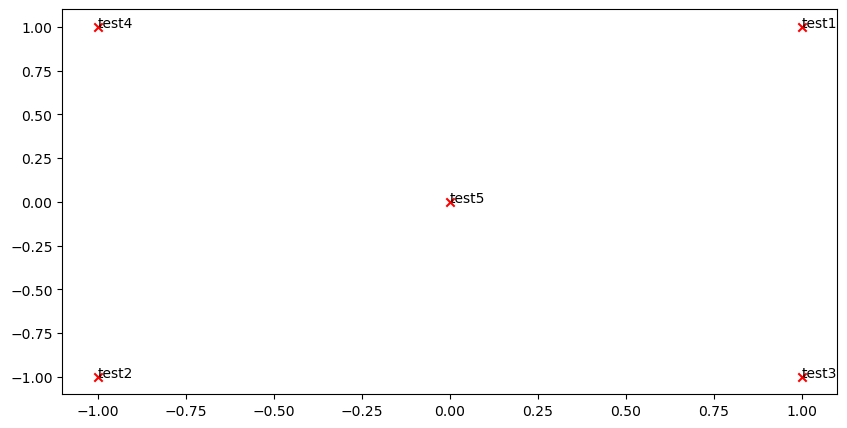

In [10]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the included file question_1.4_test.png 
# ---------------------

print ("-" * 80)
print ("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print ("-" * 80)

### 问题 1.5：Co-Occurrence 图分析 [书面] (3 分)

现在我们把之前写好的所有部分组合起来！我们将在 Large Movie Review 语料库上，以固定窗口 4（默认窗口大小）计算共现矩阵。然后用 TruncatedSVD 计算每个词的二维 embedding。TruncatedSVD 返回 U\*S，因此我们需要对返回的向量做归一化，让所有向量都出现在单位圆附近（这样"接近"就是方向上的接近）。**注意**：下面做归一化的那行代码用到了 NumPy 的 *broadcasting（广播）* 概念。如果你不了解 broadcasting，可以看看 [Jake VanderPlas 的《Computation on Arrays: Broadcasting》](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)。

运行下面的单元格来生成图。运行可能需要几分钟。


Running Truncated SVD over 5880 words...
Done.


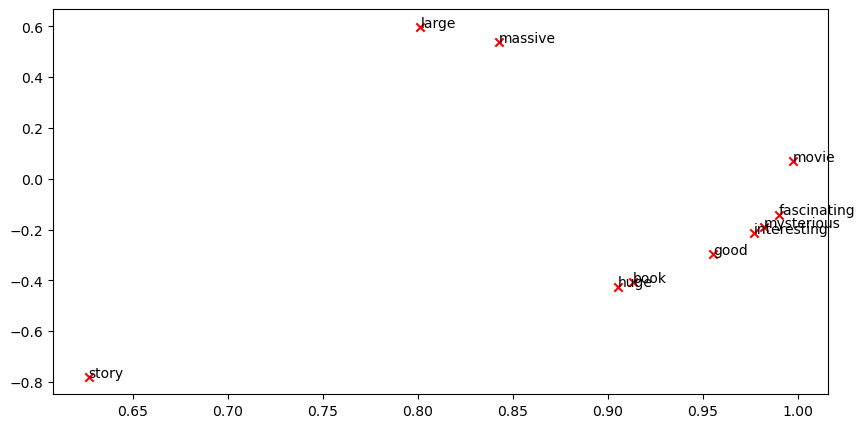

In [11]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis] # broadcasting

words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_normalized, word2ind_co_occurrence, words)

**请确认你的图与作业压缩包中的 "question_1.5.png" 一致。如果不一致，请用 "question_1.5.png" 中的图来回答下面两个问题。**

a. 找出至少两组在二维 embedding 空间中聚集在一起的词。对你观察到的每个聚类给出解释。

#### <font color="red">在这里写下你的答案。</font>

b. 有哪些你认为本应聚集在一起、但实际上并没有聚集在一起的词？至少描述两个例子。

#### <font color="red">在这里写下你的答案。</font>

## 第 2 部分：基于预测的词向量 (15 分)

正如课上所讨论的，近年来基于预测的词向量表现出了更好的性能，例如 word2vec 和 GloVe（后者也利用了计数的优势）。这里，我们将探索 GloVe 生成的 embedding。关于 word2vec 和 GloVe 算法的更多细节，请回顾课堂笔记和讲义。如果你有冒险精神，可以挑战一下自己，尝试阅读 [GloVe 原始论文](https://nlp.stanford.edu/pubs/glove.pdf)。

然后运行下面的单元格，把 GloVe 向量加载到内存中。**注意**：如果这是你第一次运行这些单元格（即下载 embedding 模型），需要几分钟才能运行完。如果你之前运行过这些单元格，重新运行会在不重新下载的情况下加载模型，大约需要 1 到 2 分钟。


In [12]:
def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin
wv_from_bin = load_embedding_model()


[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000


In [ ]:
print(wv_from_bin.)

KeyedVectors<vector_size=200, 400000 keys>


#### 注意：如果你收到 "reset by peer"（连接被重置）错误，请重新运行该单元格以重新开始下载。

### 对词嵌入进行降维
让我们直接比较 GloVe embedding 与共现矩阵的 embedding。为了避免内存耗尽，我们改用 40000 个 GloVe 向量的一个样本。
运行下面的单元格来：

1. 把 40000 个 GloVe 向量放入矩阵 M
2. 运行 `reduce_to_k_dim`（你写的 Truncated SVD 函数），把向量从 200 维降到 2 维。


In [13]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

In [ ]:
# -----------------------------------------------------------------
# Run Cell to Reduce 200-Dimensional Word Embeddings to k Dimensions
# Note: This should be quick to run
# -----------------------------------------------------------------
M, word2ind = get_matrix_of_vectors(wv_from_bin, words)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis] # broadcasting
print(M_lengths)
print(M_lengths[:, np.newaxis])

Shuffling words ...
Putting 400000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 400000 words...
Done.
[1.1432042 0.7682652 2.2080543 ... 1.3921205 1.5811461 2.598614 ]
[[1.1432042]
 [0.7682652]
 [2.2080543]]


**注意：如果你在本机遇到内存不足（out of memory）的问题，请尝试关闭其他应用程序以释放设备上的内存。你也可以尝试重启机器以释放额外内存，然后立即运行 jupyter notebook，看看能否正确加载词向量。如果这样做之后仍然无法在本机加载 embedding，请前往答疑时间（office hours）或联系课程助教。**

### 问题 2.1：GloVe 图分析 [书面] (3 分)

运行下面的单元格，绘制 `['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']` 这些词的 2D GloVe embedding。


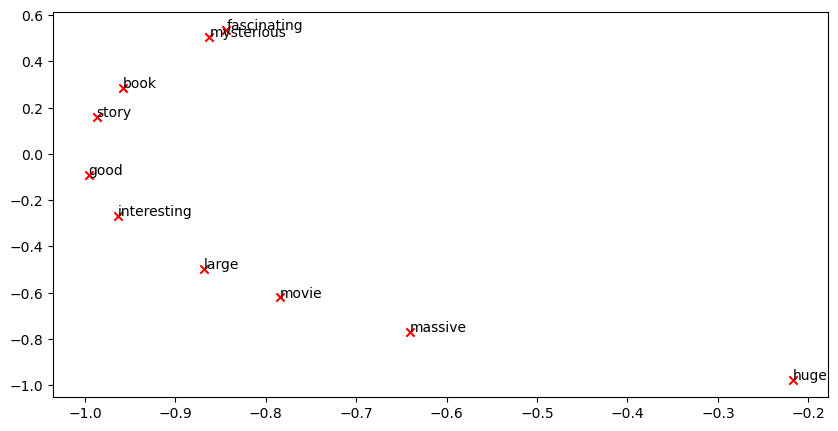

In [20]:
words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_reduced_normalized, word2ind, words)

**请确认你的图与作业压缩包中的 "question_2.1.png" 一致。如果不一致，请用 "question_2.1.png" 中的图（以及适用的 "question_1.5.png" 中的图）来回答下面两个问题。**

a. 这张图与之前由共现矩阵生成的图在哪些方面不同？在哪些方面相似？

#### <font color="red">在这里写下你的答案。</font>

b. 为什么 GloVe 图（question_2.1.png）可能与之前由共现矩阵生成的图（question_1.5.png）不同？

#### <font color="red">在这里写下你的答案。</font>

### 余弦相似度 (Cosine Similarity)
现在我们有了词向量，需要一种方法来根据这些向量量化单个词之间的相似度。其中一种度量是 cosine-similarity（余弦相似度）。我们将用它来找出彼此"接近"和"远离"的词。

我们可以把 n 维向量看作 n 维空间中的点。从这个角度看，[L1](http://mathworld.wolfram.com/L1-Norm.html) 和 [L2](http://mathworld.wolfram.com/L2-Norm.html) 距离有助于量化两个点之间"我们需要走过的"空间量。另一种方法是考察两个向量之间的夹角。由三角学可知：

<img src="./imgs/inner_product.png" width=20% style="float: center;"></img>

我们不必计算实际角度，可以把相似度表示为 $similarity = cos(\Theta)$。正式地，两个向量 $p$ 和 $q$ 之间的 [Cosine Similarity（余弦相似度）](https://en.wikipedia.org/wiki/Cosine_similarity) $s$ 定义为：

$$s = \frac{p \cdot q}{||p|| ||q||}, \textrm{ where } s \in [-1, 1] $$


### 问题 2.2：多义词 (1.5 分) [代码 + 书面]
Polyseme（多义词）和 homonym（同形/同音异义词）都是具有多个含义的词（关于多义词和同形异义词的区别，请参阅这个 [wiki 页面](https://en.wikipedia.org/wiki/Polysemy)）。找出一个具有*至少两个不同含义*的词，使得（按余弦相似度）最相似的 top-10 词中同时包含来自*这两个*含义的相关词。例如，"leaves" 在 top 10 中既有 "go_away"（离开）的含义，也有 "a_structure_of_a_plant"（植物结构）的含义；"scoop" 既有 "handed_waffle_cone"（盛华夫饼的蛋筒）也有 "lowdown"（内幕消息）。你可能需要尝试多个多义词或同形异义词才能找到一个。

请说明你发现的这个词，以及出现在 top 10 中的多个含义。你认为为什么你尝试的许多多义词或同形异义词都不奏效（即 top-10 最相似的词只包含该词的**一个**含义）？

**注意**：你应该使用 `wv_from_bin.most_similar(word)` 函数来获取 top 10 最相似的词。该函数会根据与给定词的余弦相似度对词汇表中的所有其他词进行排序。如需进一步帮助，请查看 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar)__。


In [21]:
# ------------------
# Write your implementation here.
wv_from_bin.most_similar("leaves")

# ------------------

[('ends', 0.6128067970275879),
 ('leaf', 0.6027014851570129),
 ('stems', 0.5998532176017761),
 ('takes', 0.5902854800224304),
 ('leaving', 0.5761634111404419),
 ('grows', 0.5663396716117859),
 ('flowers', 0.5600922107696533),
 ('turns', 0.5536050796508789),
 ('leave', 0.5496848821640015),
 ('goes', 0.5434925556182861)]

#### <font color="red">在这里写下你的答案。</font>

### 问题 2.3：同义词与反义词 (2 分) [代码 + 书面]

在考虑余弦相似度时，通常更方便的做法是考虑余弦距离（Cosine Distance），它其实就是 1 减去余弦相似度。

找出三个词 $(w_1,w_2,w_3)$，其中 $w_1$ 和 $w_2$ 是同义词，$w_1$ 和 $w_3$ 是反义词，但 Cosine Distance $(w_1,w_3) <$ Cosine Distance $(w_1,w_2)$。

例如，$w_1$="happy" 与 $w_3$="sad" 的距离比与 $w_2$="cheerful" 更近。请找出一个满足上述条件的*不同*例子。找到例子后，请对这个有违直觉的结果给出一个可能的解释。

这里你应该使用 `wv_from_bin.distance(w1, w2)` 函数来计算两个词之间的余弦距离。如需进一步帮助，请查看 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance)__。


In [ ]:
# ------------------
# Write your implementation here.
a = wv_from_bin.distance("big","small")
b = wv_from_bin.distance("big","large")
print(a,b)
# ------------------

0.3497811 0.33401322


#### <font color="red">在这里写下你的答案。</font>

### 问题 2.4：用词向量做类比 [书面] (1.5 分)
词向量已被证明*有时*具有解决类比问题的能力。

例如，对于类比 "man : grandfather :: woman : x"（读作：man 之于 grandfather，如同 woman 之于 x），x 是什么？

在下面的单元格中，我们展示了如何使用词向量和 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__ 中的 `most_similar` 函数来求 x。该函数找出与 `positive` 列表中的词最相似、与 `negative` 列表中的词最不相似的词（同时会省略输入词本身，它们通常是最相似的；见[这篇论文](https://www.aclweb.org/anthology/N18-2039.pdf)）。类比的答案将是余弦相似度最高（返回的数值最大）的那个词。


In [32]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005683183670044),
 ('father', 0.6659887433052063),
 ('aunt', 0.6623408794403076),
 ('grandson', 0.6618767380714417),
 ('grandparents', 0.644661009311676),
 ('wife', 0.644535481929779)]


设 $m$、$g$、$w$ 和 $x$ 分别表示 `man`、`grandfather`、`woman` 和答案的词向量。在你的答案中**只**使用向量 $m$、$g$、$w$，以及向量算术运算符 $+$ 和 $-$，写出我们要最大化与 $x$ 的余弦相似度的那个表达式。

提示：回想一下，词向量其实就是表示一个词的多维向量。用每个向量任意放置的位置画一个 2D 例子可能会有帮助。`man` 和 `woman` 相对于 `grandfather` 和答案，会落在坐标平面的什么位置？


#### <font color="red">在这里写下你的答案。</font>

### 问题 2.5：寻找类比 [代码 + 书面] (1.5 分)
a. 对于上面的例子，很明显 "grandmother" 完成了这个类比。但请直观地解释，为什么 `most_similar` 函数会给出像 "granddaughter"、"daughter" 或 "mother" 这样的词？

#### <font color="red">在这里写下你的答案。</font>

b. 找一个根据这些向量能够成立的类比例子（即预期的词排在第一名）。在你的答案中，请以 x:y :: a:b 的形式完整地写出这个类比。如果你认为这个类比很复杂，请用一两句话解释这个类比为什么成立。

**注意**：你可能需要尝试很多个类比才能找到一个成立的！

In [35]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.
pprint.pprint(wv_from_bin.most_similar(positive=['country', 'brain'], negative=['human']))

# ------------------

# Test the solution
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] == b

[('heart', 0.4888848066329956),
 ('nation', 0.45749902725219727),
 ('rest', 0.42317628860473633),
 ('once', 0.4084964990615845),
 ('already', 0.40773457288742065),
 ('spinal', 0.40617960691452026),
 ('now', 0.4048677384853363),
 ('stroke', 0.40399444103240967),
 ('surgery', 0.4038344621658325),
 ('weeks', 0.402807354927063)]


NameError: name 'y' is not defined

#### <font color="red">在这里写下你的答案。</font>

### 问题 2.6：不成立的类比 [代码 + 书面] (1.5 分)
a. 下面，我们本期望看到预期的类比 "hand : glove :: foot : **sock**"，但结果却出乎意料。请给出一个可能的原因，说明为什么这个特定的类比会出现这样的结果？

In [33]:
pprint.pprint(wv_from_bin.most_similar(positive=['foot', 'glove'], negative=['hand']))

[('45,000-square', 0.4922032058238983),
 ('15,000-square', 0.4649604558944702),
 ('10,000-square', 0.45447564125061035),
 ('6,000-square', 0.44975772500038147),
 ('3,500-square', 0.4441334009170532),
 ('700-square', 0.44257503747940063),
 ('50,000-square', 0.4356396794319153),
 ('3,000-square', 0.43486514687538147),
 ('30,000-square', 0.4330596923828125),
 ('footed', 0.43236875534057617)]


#### <font color="red">在这里写下你的答案。</font>

b. 再找一个根据这些向量*不*成立的类比例子。在你的答案中，以 x:y :: a:b 的形式写出预期的类比，并根据词向量写出 b 的**错误**值（在上面的例子中，这个值是 **'45,000-square'**）。

In [ ]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.


# ------------------
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] != b

#### <font color="red">在这里写下你的答案。</font>

### 问题 2.7：词向量偏见的引导式分析 [书面] (1 分)

意识到我们的词嵌入中隐含的偏见（性别、种族、性取向等）非常重要。偏见可能是危险的，因为使用这些模型的应用可能会强化刻板印象。

运行下面的单元格，考察 (a) 哪些词与 "man" 和 "profession" 最相似、与 "woman" 最不相似，以及 (b) 哪些词与 "woman" 和 "profession" 最相似、与 "man" 最不相似。指出与女性相关的词列表和与男性相关的词列表之间的差异，并解释它如何反映了性别偏见。


In [36]:
# Run this cell
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.

pprint.pprint(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404),
 ('professions', 0.5178037881851196),
 ('skill', 0.49046966433525085),
 ('skills', 0.49005505442619324),
 ('ethic', 0.4897659420967102),
 ('business', 0.487585186958313),
 ('respected', 0.4859202802181244),
 ('practice', 0.482104629278183),
 ('regarded', 0.4778572916984558),
 ('life', 0.4760662019252777)]

[('professions', 0.5957458019256592),
 ('practitioner', 0.4988412857055664),
 ('teaching', 0.48292139172554016),
 ('nursing', 0.48211804032325745),
 ('vocation', 0.4788965880870819),
 ('teacher', 0.47160348296165466),
 ('practicing', 0.46937811374664307),
 ('educator', 0.46524327993392944),
 ('physicians', 0.4628995656967163),
 ('professionals', 0.4601394236087799)]


#### <font color="red">在这里写下你的答案。</font>

### 问题 2.8：词向量偏见的独立分析 [代码 + 书面] (1 分)

使用 `most_similar` 函数找出另一对类比，以证明向量表现出了某种偏见。请简要解释你发现的这个偏见例子。


In [ ]:
# ------------------
# Write your implementation here.


# ------------------

#### <font color="red">在这里写下你的答案。</font>

### 问题 2.9：关于偏见的思考 [书面] (2 分)

a. 给出一种解释，说明偏见是如何进入词向量的。简要描述一个真实世界的例子，来证明这个偏见来源。你的真实世界例子应聚焦于词向量，而不是其他 AI 系统（如 ChatGPT）中的偏见。


#### <font color="red">在这里写下你的答案。</font>

b. 你可以用什么方法来缓解词向量表现出的偏见？简要描述一个真实世界的例子，来证明这个方法。

#### <font color="red">在这里写下你的答案。</font>

# <font color="blue"> 提交说明</font>

1. 点击 Jupyter Notebook 顶部的 Save（保存）按钮。
2. 选择 Cell -> All Output -> Clear（清除所有输出）。这会清除所有单元格的输出（但保留所有单元格的内容）。
2. 选择 Cell -> Run All（全部运行）。这会按顺序运行所有单元格，需要几分钟时间。
3. 重新运行完所有内容后，选择 File -> Download as -> PDF via LaTeX（通过 LaTeX 下载为 PDF）（如果你在 "PDF via LaTex" 上遇到问题，也可以把网页保存为 pdf。<font color='blue'>请确保你所有的答案，尤其是代码部分，都显示在 pdf 中</font>，提供的代码因为代码单元格不换行而被截断是没关系的）。
4. 查看 PDF 文件，确保你所有的答案都在里面，并且显示正确。PDF 是评分人唯一能看到的东西！
5. 在 Gradescope 上提交你的 PDF。

In [8]:
a = [1,2,3]
b = a.copy()
b[1] = 55
a



[1, 2, 3]

In [5]:
print(a)


[1]
